# Fraud Detection Using Machine Learning

## 1. Load Dataset

This project focuses on detecting fraudulent financial transactions using machine learning techniques on an imbalanced credit card transaction dataset.

In [ ]:
df = pd.read_csv("creditcard.csv")
print(df.shape)
df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Class Imbalance Analysis

The dataset contains two classes:
- Class 0: Non-fraudulent transactions
- Class 1: Fraudulent transactions

We will calculate the number and percentage of fraudulent and non-fraudulent transactions to understand the class imbalance.

In [ ]:
print(df['Class'].value_counts())

print("\nPercentage:")
print(df['Class'].value_counts(normalize=True) * 100)

Class
0    284315
1       492
Name: count, dtype: int64

Percentage:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


## 3. Transaction Amount Distribution

We will analyse the distribution of transaction amounts for fraudulent and non-fraudulent transactions.

This helps us understand whether transaction amounts show different patterns between the two classes.

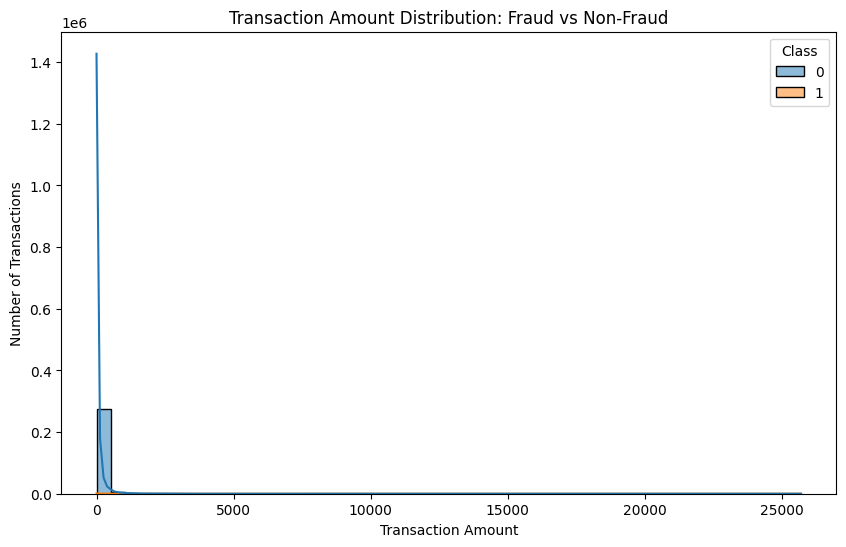

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='Amount',
    hue='Class',
    bins=50,
    kde=True
)

plt.title('Transaction Amount Distribution: Fraud vs Non-Fraud')
plt.xlabel('Transaction Amount')
plt.ylabel('Number of Transactions')
plt.show()

## 4. Time-of-Day Analysis

The `Time` column represents the time elapsed since the first transaction in the dataset.

We will convert this value into hours of the day and analyse the occurrence of fraudulent and non-fraudulent transactions across different hours.

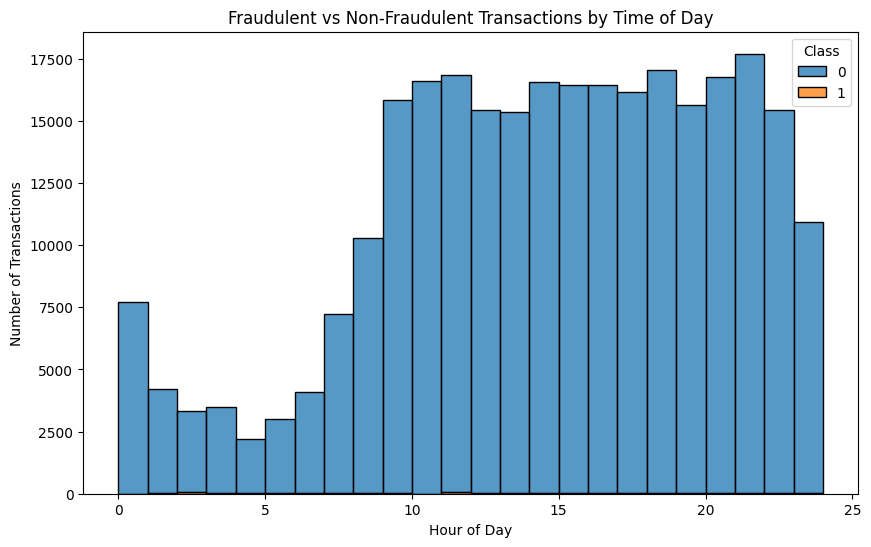

In [ ]:
df['Hour'] = (df['Time'] / 3600) % 24

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='Hour',
    hue='Class',
    bins=24,
    multiple='stack'
)

plt.title('Fraudulent vs Non-Fraudulent Transactions by Time of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Transactions')
plt.show()

## 5. Why Accuracy Is Misleading

The dataset is highly imbalanced, with approximately 99.83% non-fraudulent transactions and only 0.17% fraudulent transactions.

In such an imbalanced dataset, accuracy alone can be misleading. A model that predicts almost every transaction as non-fraudulent could achieve very high accuracy while failing to detect fraudulent transactions.

Therefore, we will use Precision, Recall, F1-Score, and AUC-ROC to evaluate the fraud detection models.

## 6. Train-Test Split with Stratification

The dataset will be divided into training and testing sets.

Stratification is used to maintain the same proportion of fraudulent and non-fraudulent transactions in both the training and testing datasets.

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X = df.drop(['Class', 'Hour'], axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)
print("\nFraud cases in training set:", y_train.sum())
print("Fraud cases in testing set:", y_test.sum())

Training set: (227845, 30)
Testing set: (56962, 30)

Fraud cases in training set: 394
Fraud cases in testing set: 98


## 7. Handling Class Imbalance Using SMOTE

The dataset is highly imbalanced, with very few fraudulent transactions compared with non-fraudulent transactions.

SMOTE (Synthetic Minority Over-sampling Technique) is used to generate synthetic samples of the minority class.

SMOTE will be applied only to the training data to avoid data leakage into the test set.

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


## 8. Logistic Regression Model

Logistic Regression is used as the first classification model to predict whether a transaction is fraudulent or non-fraudulent.

The model is trained using the SMOTE-balanced training data.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train_smote)

y_pred_lr = logistic_model.predict(X_test_scaled)
y_prob_lr = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


## 9. Random Forest Model

Random Forest is an ensemble machine learning algorithm that combines multiple decision trees to make predictions.

It is used as the second model to compare its fraud detection performance with Logistic Regression.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train_smote, y_train_smote)

y_pred_rf = random_forest_model.predict(X_test)
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


## 10. Model Evaluation

The Logistic Regression and Random Forest models will be evaluated using Precision, Recall, F1-Score, and AUC-ROC.

These metrics are more suitable than accuracy for fraud detection because the dataset is highly imbalanced.

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# Logistic Regression metrics
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_auc = roc_auc_score(y_test, y_prob_lr)

# Random Forest metrics
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_prob_rf)

print("Logistic Regression")
print("Precision:", lr_precision)
print("Recall:", lr_recall)
print("F1-Score:", lr_f1)
print("AUC-ROC:", lr_auc)

print("\nRandom Forest")
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1-Score:", rf_f1)
print("AUC-ROC:", rf_auc)

Logistic Regression
Precision: 0.13414634146341464
Recall: 0.8979591836734694
F1-Score: 0.23342175066312998
AUC-ROC: 0.9764816590676788

Random Forest
Precision: 0.8350515463917526
Recall: 0.826530612244898
F1-Score: 0.8307692307692308
AUC-ROC: 0.9644232605112952


## 11. AUC-ROC Curve

The ROC curve shows the trade-off between the True Positive Rate (Recall) and False Positive Rate at different classification thresholds.

The Area Under the Curve (AUC) measures the model's ability to distinguish between fraudulent and non-fraudulent transactions.

A higher AUC indicates better classification performance.

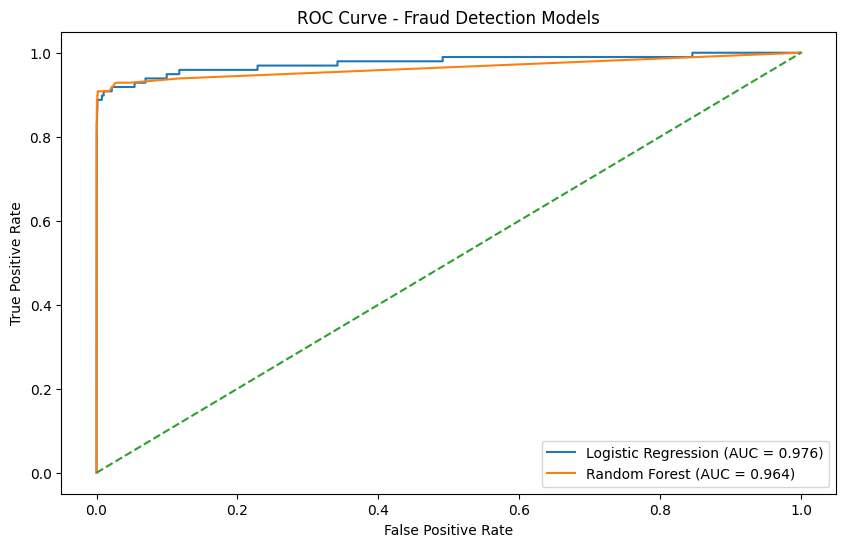

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# ROC curve for Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)

# ROC curve for Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

# Calculate AUC
auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_rf = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(10, 6))

plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--')

plt.title('ROC Curve - Fraud Detection Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

## 12. Feature Importance

Random Forest provides feature importance scores that show how strongly each feature contributes to the model's predictions.

We will identify and visualize the most important features used for fraud detection.

   Feature  Importance
14     V14    0.217013
10     V10    0.119797
4       V4    0.116789
12     V12    0.107501
17     V17    0.086248
3       V3    0.070860
11     V11    0.050472
16     V16    0.040096
2       V2    0.038845
9       V9    0.028277


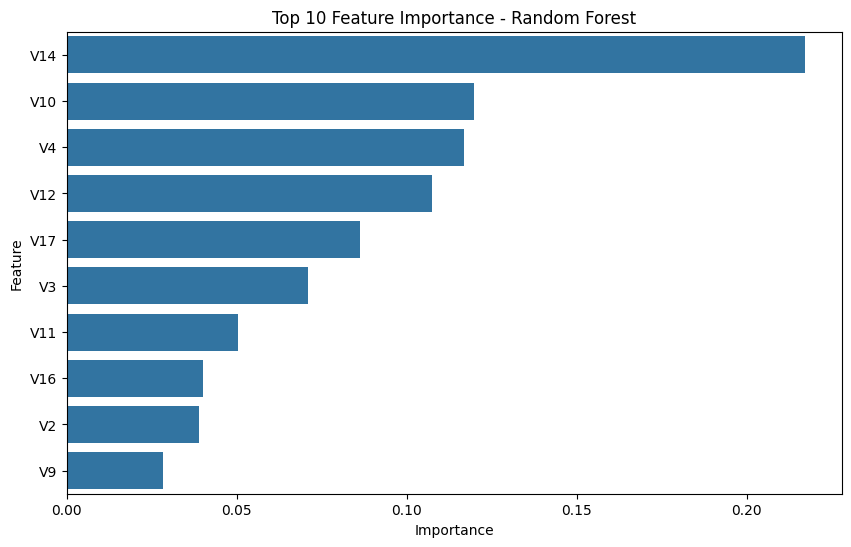

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

## 13. Recall vs Precision Trade-off

In fraud detection, Recall is an important metric because it measures how many actual fraudulent transactions are correctly detected.

A high Recall helps reduce missed fraud cases. However, increasing Recall can sometimes reduce Precision, causing more genuine transactions to be incorrectly flagged as fraudulent.

Precision measures how many transactions predicted as fraud are actually fraudulent.

For fraud detection, Recall is generally given high importance because missing a fraudulent transaction can be more costly than investigating a false alert.

## 14. Scalability for 1 Million Transactions per Hour

For a large-scale fraud detection system processing 1 million transactions per hour, the system should be designed for efficient and scalable processing.

The trained machine learning model can be deployed as an API service to make predictions on new transactions.

Batch processing or streaming systems can be used to process large numbers of transactions efficiently.

The model can also be optimized using parallel processing and scalable cloud infrastructure.

For real-time fraud detection, transactions can be processed through a streaming architecture where each transaction is evaluated quickly and suspicious transactions are flagged for further investigation.